# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html
## Setup
Import dependencies and configure paths.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import torch
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path(os.environ.get("SCBIOT_EXAMPLES_PATH", Path.cwd()))
print(dir)
parent_dir = dir.parent
print(parent_dir)


scbiot version 1.1.8
Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


## Load
Read the lung atlas dataset from disk.

In [2]:
adata_path = f"{dir}/inputs/lung_atlas.h5ad"

adata = sc.read(
    adata_path,
    backup_url="https://figshare.com/ndownloader/files/24539942",
)
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [3]:
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

## Preprocess
(Optional) normalize and select variable genes for PCA.

In [4]:
# sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key='batch')
# sc.pp.scale(adata)
# sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

## Integrate
Run centroid-level OT integration on the PCA space.

In [5]:
adata, metrics = scb.ot.integrate(adata, 
                                obsm_key='X_pca', 
                                batch_key='batch', 
                                out_key='X_ot',
                                centroid=True,
                                n_centroids_per_batch=512,   # tune: fewer = faster, more = better fidelity
                                max_samples_per_batch=500_000,
                                k_interp=8,                              
                                chunk_size=500_000
                                )
print(metrics)

[baseline] KNN backend=FAISS-GPU mix=0.9670 strain=0.00307
[iter 01] mix=1.016 overlap0=0.936 strain=0.00380 floor~0.600 J=0.207 best_it=1
[iter 02] mix=1.061 overlap0=0.894 strain=0.00513 floor~0.607 J=0.252 best_it=2
[iter 03] mix=1.103 overlap0=0.859 strain=0.00707 floor~0.614 J=0.288 best_it=3
[iter 04] mix=1.146 overlap0=0.823 strain=0.00985 floor~0.621 J=0.321 best_it=4
[iter 05] mix=1.186 overlap0=0.786 strain=0.01302 floor~0.629 J=0.349 best_it=5
[iter 06] mix=1.227 overlap0=0.751 strain=0.01743 floor~0.636 J=0.380 best_it=6
[iter 07] mix=1.274 overlap0=0.711 strain=0.02268 floor~0.643 J=0.412 best_it=7
[iter 08] mix=1.318 overlap0=0.668 strain=0.02934 floor~0.650 J=0.439 best_it=8
[iter 09] mix=1.351 overlap0=0.640 strain=0.03669 floor~0.657 J=0.465 best_it=9
[iter 10] mix=1.389 overlap0=0.599 strain=0.04460 floor~0.664 J=0.476 best_it=10
[iter 11] mix=1.420 overlap0=0.572 strain=0.05034 floor~0.671 J=0.493 best_it=11
[iter 12] mix=1.446 overlap0=0.545 strain=0.05785 floor~0.6

## Visualize
Compare batch and Leiden structure across embeddings in UMAP panels.

In [7]:
# same as above, run neighbors/UMAP for each embedding
methods = ["X_ot"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata, use_rep=method)
    sc.tl.umap(adata)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata, key_added=leiden_method, resolution=0.8)

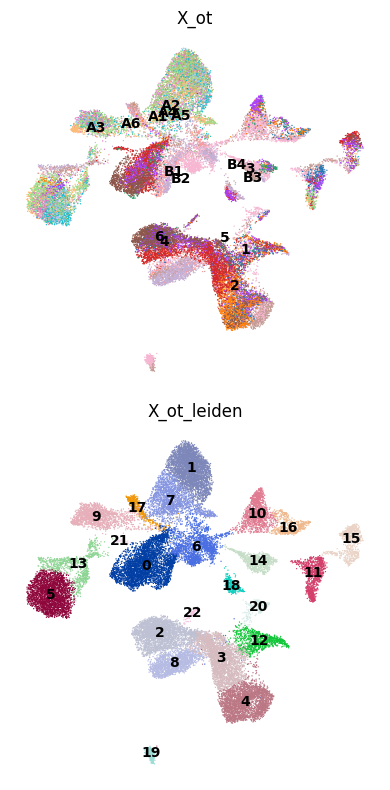

In [8]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",
        color=leiden_key,         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


## Evaluate (scib-metrics)
Note: if scib-metrics errors, update `_graph_connectivity.py` to use `(labels == label).to_numpy()`.

In [9]:
bm = Benchmarker(
    adata, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_ot"], 
    n_jobs=-1
    
)
bm.benchmark()

Embeddings: 100%|██████████| 2/2 [00:48<00:00, 24.32s/it]


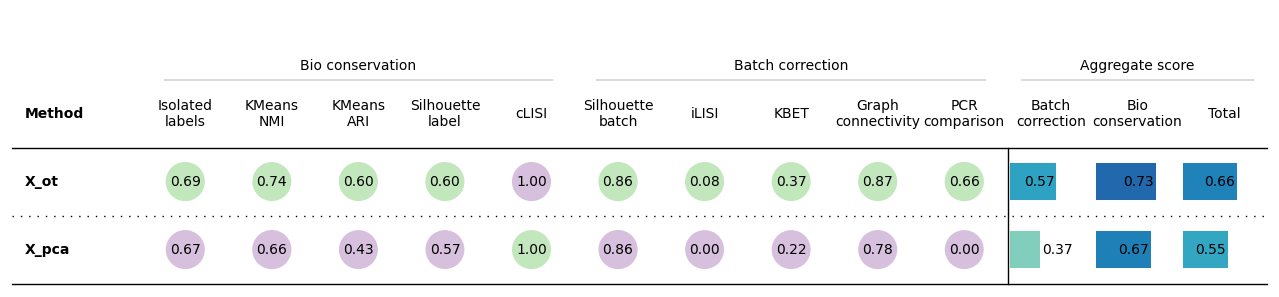

In [10]:
bm.plot_results_table(min_max_scale=False)